# TabularBench Metric Analysis: ADV/ADV+CTR Gap & Ranking Sensitivity

**Date:** 2026-03-31
**Dataset:** LCLD (Lending Club Loan Data)
**Execution environment:** Google Colab (GPU for Direction 3)

---

## Overview

This notebook produces two independent analyses for the FraudBench ICAIF 2026 paper:

1. **Direction 3 (Cells 1–5, GPU required):** Map FraudBench's LCLD results into TabularBench's ADV / ADV+CTR evaluation framework. Computes per-sample constrained adversarial recall and shows that post-hoc constraint filtering renders CAPGD attacks ineffective.

2. **Direction 7 (Cells 6–10, pure analysis):** Re-rank TabularBench's LCLD leaderboard under alternative metrics (F1, MCC, AUC, harmonic mean) to demonstrate that accuracy-based ranking is misleading for fraud detection.

**Instructions:**
- Run Cell 1 once, then **restart the runtime** (Runtime > Restart session)
- After restart, skip Cell 1 and run from Cell 2 onwards
- Direction 7 (Cells 6–10) can be run independently of Direction 3

In [1]:
# Cell 1: Setup — mount Drive, clone repo, install deps
# Run this cell once, then restart runtime (Runtime > Restart session).
# After restart, skip this cell and run from Cell 2.

import torch
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    gpu_mem = getattr(props, "total_memory", getattr(props, "total_mem", 0)) / 1e9
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    print("WARNING: No GPU detected — Direction 3 requires GPU for model training")

from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_ROOT = "/content/drive/MyDrive/FraudBench"
for subdir in ["data", "results", "results/adv_examples", "results/metric_analysis"]:
    os.makedirs(os.path.join(DRIVE_ROOT, subdir), exist_ok=True)
print("Google Drive mounted.")

REPO_DIR = "/content/Capstone_FraudBench"
if os.path.exists(os.path.join(REPO_DIR, ".git")):
    os.chdir(REPO_DIR)
    !git pull
else:
    os.chdir("/content")
    if os.path.exists(REPO_DIR):
        import shutil; shutil.rmtree(REPO_DIR)
    !git clone https://github.com/iHaydenzZ/Capstone_FraudBench.git {REPO_DIR}
    os.chdir(REPO_DIR)

print(f"Working directory: {os.getcwd()}")
!git log --oneline -3

!pip install "numpy<2.1" "scipy>=1.14,<1.15" "scikit-learn>=1.5" -q 2>&1 | tail -3
!pip install -e . --no-deps -q 2>&1 | tail -3
!pip install "numba>=0.61" xgboost torch art pyyaml joblib pandas matplotlib -q 2>&1 | tail -3

print("\n>>> RESTART RUNTIME NOW, then skip this cell and run from Cell 2 <<<")

GPU: NVIDIA A100-SXM4-40GB (42.4 GB)
Mounted at /content/drive
Google Drive mounted.
Cloning into '/content/Capstone_FraudBench'...
remote: Enumerating objects: 748, done.
remote: Counting objects: 100% (748/748), done.
remote: Compressing objects: 100% (436/436), done.
remote: Total 748 (delta 450), reused 592 (delta 294), pack-reused 0 (from 0)
Receiving objects: 100% (748/748), 2.11 MiB | 7.97 MiB/s, done.
Resolving deltas: 100% (450/450), done.
Working directory: /content/Capstone_FraudBench
c920d7b (HEAD -> master, origin/master, origin/HEAD) feat: add TabularBench metric analysis notebook and experiment plan
e3270fb docs: add TabularBench comparison findings with corrected feasibility rates
c99808e chore: gitignore tabularbench/ external clone
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 62.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the pac

In [1]:
# Cell 2: Load artifacts, re-train model, get predictions
# Run this cell after runtime restart. Skip Cell 1.

import os, time
import pandas as pd
import numpy as np

# Re-establish environment after restart
if not os.path.exists("/content/drive/MyDrive"):
    from google.colab import drive
    drive.mount('/content/drive')

os.chdir("/content/Capstone_FraudBench")
DRIVE_ROOT = "/content/drive/MyDrive/FraudBench"
DRIVE_ADV  = os.path.join(DRIVE_ROOT, "results/adv_examples")
DRIVE_DATA = os.path.join(DRIVE_ROOT, "data")

# Symlink datasets (needed for load_dataset + preprocessor fitting)
DATASETS_DIR = "/content/Capstone_FraudBench/datasets"
for d in ["CCFD", "ieee-fraud-detection", "LCLD", "Sparkov"]:
    src = os.path.join(DRIVE_DATA, d)
    dst = os.path.join(DATASETS_DIR, d)
    if os.path.islink(dst):
        os.unlink(dst)
    elif os.path.isdir(dst):
        import shutil; shutil.rmtree(dst)
    if os.path.exists(src):
        os.symlink(src, dst)
        print(f"  Linked: {d}/")

# --- Load saved artifacts from Google Drive ---
print("\nLoading saved artifacts from Drive...")
X_test_raw    = pd.read_parquet(os.path.join(DRIVE_ADV, "lcld_Xtest_raw_seed42.parquet"))
X_test_p      = pd.read_parquet(os.path.join(DRIVE_ADV, "lcld_Xtest_processed_seed42.parquet"))
y_test        = pd.read_parquet(os.path.join(DRIVE_ADV, "lcld_ytest_seed42.parquet")).squeeze()
X_adv_un_proc = pd.read_parquet(os.path.join(DRIVE_ADV, "lcld_neural_unmasked_seed42.parquet"))
X_adv_mk_proc = pd.read_parquet(os.path.join(DRIVE_ADV, "lcld_neural_masked_seed42.parquet"))
df_derived    = pd.read_parquet(os.path.join(DRIVE_ADV, "lcld_derived_features_sampled.parquet"))

print(f"  X_test_p:      {X_test_p.shape}")
print(f"  X_adv_un_proc: {X_adv_un_proc.shape}")
print(f"  X_adv_mk_proc: {X_adv_mk_proc.shape}")
print(f"  y_test:        {y_test.shape}  (pos rate: {y_test.mean():.4f})")
print(f"  df_derived:    {df_derived.shape}")

# --- Re-train model (also fits preprocessor needed for Cell 3) ---
from datasets.loader import load_dataset
from datasets.splitter import split_dataset
from preprocessing.processor import DataPreprocessor, get_preprocessor_path
from models.neural import NeuralModel
from evaluation.metrics import compute_metrics

SEED = 42
SAMPLE_FRAC = 0.1

print("\nLoading dataset and re-training model...")
dataset = load_dataset("lcld", config={"sample_frac": SAMPLE_FRAC})
X_train, X_val, X_test_split, y_train, y_val, y_test_split = split_dataset(
    dataset, test_size=0.2, val_size=0.2, random_state=SEED,
)
print(f"  Data: train={len(X_train)}, test={len(X_test_split)}, features={X_train.shape[1]}")

pp_path = get_preprocessor_path("lcld", SEED, len(dataset.X))
if os.path.exists(pp_path):
    preprocessor = DataPreprocessor.load(pp_path)
    X_train_p = preprocessor.transform(X_train)
    print(f"  Loaded cached preprocessor from {pp_path}")
else:
    preprocessor = DataPreprocessor(dataset.feature_types)
    X_train_p = preprocessor.fit_transform(X_train)
    preprocessor.save(pp_path)
    print(f"  Fitted and saved preprocessor to {pp_path}")

model_params = {"epochs": 20, "hidden_dim": 128, "batch_size": 256, "lr": 0.001}
model = NeuralModel(model_params)
t0 = time.time()
model.fit(X_train_p, y_train)
print(f"  Trained in {time.time() - t0:.1f}s")

# --- Get predictions on saved test/adversarial data ---
y_probs_clean    = model.predict_proba(X_test_p)
y_probs_unmasked = model.predict_proba(X_adv_un_proc)
y_probs_masked   = model.predict_proba(X_adv_mk_proc)

y_pred_clean    = (y_probs_clean >= 0.5).astype(int)
y_pred_unmasked = (y_probs_unmasked >= 0.5).astype(int)
y_pred_masked   = (y_probs_masked >= 0.5).astype(int)

# --- Sanity check ---
m_clean = compute_metrics(y_test, y_probs_clean)
print(f"\nSanity check (clean predictions):")
print(f"  clean_pr_auc   = {m_clean['pr_auc']:.4f}  (expect ~0.30)")
print(f"  clean_accuracy = {m_clean['accuracy']:.4f}  (expect ~0.64)")
print(f"  clean_recall   = {m_clean['recall']:.4f}  (expect ~0.56)")

  Linked: CCFD/
  Linked: ieee-fraud-detection/
  Linked: LCLD/
  Linked: Sparkov/

Loading saved artifacts from Drive...
  X_test_p:      (26820, 188)
  X_adv_un_proc: (26820, 188)
  X_adv_mk_proc: (26820, 188)
  y_test:        (26820,)  (pos rate: 0.1959)
  df_derived:    (134097, 6)

Loading dataset and re-training model...
    Split indices saved to results/split_indices_lcld_n134097_seed42.json
  Data: train=80457, test=26820, features=63
    Preprocessor saved to results/preprocessor_lcld_n134097_seed42.joblib
  Fitted and saved preprocessor to results/preprocessor_lcld_n134097_seed42.joblib
  Using class weights (pos_weight=4.11)
Training Neural Model on cuda...
Epoch 5/20, Loss: 0.9703
Epoch 10/20, Loss: 0.9080
Epoch 15/20, Loss: 0.8165
Epoch 20/20, Loss: 0.7187
  Trained in 26.4s

Sanity check (clean predictions):
  clean_pr_auc   = 0.3032  (expect ~0.30)
  clean_accuracy = 0.6407  (expect ~0.64)
  clean_recall   = 0.5542  (expect ~0.56)


In [2]:
# Cell 3: Inverse-transform + derived features + constraint functions
#
# This cell:
#   1. Inverse-transforms adversarial examples from processed space to raw space
#   2. Reconstructs derived features and term from OHE
#   3. Defines all TabularBench constraint functions (g1-g6)
#   4. Defines compute_aggregate_feasibility()
#
# Functions are copied from tabularbench_comparison.ipynb Cells 11-13.

import re
import numpy as np
import pandas as pd

# =====================================================================
# PART 1: Inverse-transform processed space -> raw feature space
# =====================================================================

# Extract StandardScaler from the preprocessor's ColumnTransformer
ct = preprocessor.pipeline
num_feature_names = []
scaler = None
for name, transformer, columns in ct.transformers_:
    if name == "num":
        scaler = transformer.named_steps["scaler"]
        num_feature_names = list(columns)
        break

print(f"Numeric features in preprocessor: {len(num_feature_names)}")


def inverse_transform_numeric(X_proc, num_feature_names, scaler):
    """Inverse-transform only the numeric columns from processed space
    back to raw space using the fitted StandardScaler."""
    sanitize = lambda c: re.sub(r"[\[\]<>]", "_", c)
    sanitized_num = [sanitize(c) for c in num_feature_names]

    proc_cols = X_proc.columns.tolist()
    matched = [(raw, san) for raw, san in zip(num_feature_names, sanitized_num) if san in proc_cols]

    raw_names = [m[0] for m in matched]
    san_names = [m[1] for m in matched]
    idx_in_scaler = [num_feature_names.index(r) for r in raw_names]

    X_scaled = X_proc[san_names].values
    means = scaler.mean_[idx_in_scaler]
    scales = scaler.scale_[idx_in_scaler]
    X_raw_vals = X_scaled * scales + means

    return pd.DataFrame(X_raw_vals, columns=raw_names, index=X_proc.index)


X_test_inv   = inverse_transform_numeric(X_test_p, num_feature_names, scaler)
X_adv_un_inv = inverse_transform_numeric(X_adv_un_proc, num_feature_names, scaler)
X_adv_mk_inv = inverse_transform_numeric(X_adv_mk_proc, num_feature_names, scaler)

# Sanity: compare inverse-transformed test vs original raw
shared_cols = [c for c in X_test_inv.columns if c in X_test_raw.columns]
max_diff = (X_test_inv[shared_cols].values - X_test_raw[shared_cols].values)
valid_mask = ~np.isnan(max_diff)
if valid_mask.any():
    print(f"  Inverse-transform sanity: max error = {np.abs(max_diff[valid_mask]).max():.6f}")

print(f"  X_test_inv:   {X_test_inv.shape}")
print(f"  X_adv_un_inv: {X_adv_un_inv.shape}")
print(f"  X_adv_mk_inv: {X_adv_mk_inv.shape}")

# =====================================================================
# PART 2: Derived features + term reconstruction
# =====================================================================

# Align derived features to test set indices
derived_for_test = df_derived.iloc[X_test_raw.index].reset_index(drop=True)


def add_derived_from_base(df_inv, derived_template):
    """Recompute derived ratios from perturbed base features."""
    df = df_inv.copy()
    if "annual_inc" in df.columns and "loan_amnt" in df.columns:
        df["ratio_loan_amnt_annual_inc"] = (
            df["loan_amnt"] / df["annual_inc"].replace(0, np.nan)
        )
    if "open_acc" in df.columns and "total_acc" in df.columns:
        df["ratio_open_acc_total_acc"] = (
            df["open_acc"] / df["total_acc"].replace(0, np.nan)
        )
    # Copy month_since_earliest_cr_line from template (date-derived, not perturbed)
    if "month_since_earliest_cr_line" in derived_template.columns:
        df["month_since_earliest_cr_line"] = derived_template["month_since_earliest_cr_line"].values
    return df


def reconstruct_term_from_ohe(X_proc):
    """Reconstruct raw term value (36 or 60) from OHE columns in processed space."""
    proc_cols = X_proc.columns.tolist()
    term_cols = [c for c in proc_cols if c.startswith("term_")]
    if len(term_cols) == 0:
        return None

    term_vals = {}
    for col in term_cols:
        val = pd.to_numeric(
            col.replace("term_", "").replace("months", "").strip(),
            errors="coerce",
        )
        if not np.isnan(val):
            term_vals[col] = val

    if not term_vals:
        return None

    term_df = X_proc[list(term_vals.keys())]
    best_col = term_df.idxmax(axis=1)
    return best_col.map(term_vals)


# Build raw-space DataFrames with derived features
df_test_raw = add_derived_from_base(X_test_inv, derived_for_test)
df_adv_un   = add_derived_from_base(X_adv_un_inv, derived_for_test)
df_adv_mk   = add_derived_from_base(X_adv_mk_inv, derived_for_test)

# Reconstruct term from OHE for all DataFrames
for label, df, X_proc in [("test", df_test_raw, X_test_p),
                           ("adv_un", df_adv_un, X_adv_un_proc),
                           ("adv_mk", df_adv_mk, X_adv_mk_proc)]:
    term = reconstruct_term_from_ohe(X_proc)
    if term is not None:
        df["term"] = term.values

if "term" in df_adv_un.columns:
    print(f"\nReconstructed term for adv (unmasked): {df_adv_un['term'].value_counts().to_dict()}")
    print(f"Reconstructed term for adv (masked):   {df_adv_mk['term'].value_counts().to_dict()}")
else:
    print("\nWARNING: No term_ OHE columns found — g1/g4 checks may be limited")

# =====================================================================
# PART 3: Constraint functions (copied from tabularbench_comparison.ipynb Cell 12)
# =====================================================================

TOLERANCE = 0.01  # same as TabularBench's EqualConstraint tolerance
G1_TOL = 0.1      # 10x TabularBench's 0.01, for inverse-transform precision


def _to_float(series):
    """Coerce a Series to float, stripping non-numeric chars."""
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float)
    return pd.to_numeric(series.astype(str).str.replace(r"[^\d.\-]", "", regex=True), errors="coerce")


def check_g1_installment(df, tol=0.1):
    """g1: installment = loan_amnt * (r*(1+r)^t) / ((1+r)^t - 1)."""
    needed = ["loan_amnt", "int_rate", "installment", "term"]
    if not all(c in df.columns for c in needed):
        return None
    loan = _to_float(df["loan_amnt"])
    rate = _to_float(df["int_rate"])
    inst = _to_float(df["installment"])
    t = _to_float(df["term"])
    r = rate / 1200.0
    expected = loan * (r * (1 + r) ** t) / ((1 + r) ** t - 1)
    diff = (inst - expected).abs()
    return diff <= tol


def check_g2_open_total(df):
    """g2: open_acc <= total_acc."""
    needed = ["open_acc", "total_acc"]
    if not all(c in df.columns for c in needed):
        return None
    return _to_float(df["open_acc"]) <= _to_float(df["total_acc"]) + TOLERANCE


def check_g3_bankruptcies(df):
    """g3: pub_rec_bankruptcies <= pub_rec."""
    needed = ["pub_rec_bankruptcies", "pub_rec"]
    if not all(c in df.columns for c in needed):
        return None
    return _to_float(df["pub_rec_bankruptcies"]) <= _to_float(df["pub_rec"]) + TOLERANCE


def check_g4_processed(X_proc):
    """g4 in processed space: check that term OHE is still valid one-hot."""
    proc_cols = X_proc.columns.tolist()
    term_cols = [c for c in proc_cols if c.startswith("term_")]
    if len(term_cols) < 2:
        return None

    term_arr = X_proc[term_cols].values
    row_max = term_arr.max(axis=1)
    row_sum = term_arr.sum(axis=1)

    tol = 0.01
    valid = (np.abs(row_max - 1.0) < tol) & (np.abs(row_sum - 1.0) < tol)
    return pd.Series(valid, index=X_proc.index)


def check_g4_term(df):
    """g4: term must be 36 or 60 (raw-space check)."""
    if "term" not in df.columns:
        return None
    t = _to_float(df["term"])
    return t.round().isin([36, 60])


def check_g5_ratio_loan_inc(df, tol=0.01):
    """g5: ratio_loan_amnt_annual_inc == loan_amnt / annual_inc."""
    needed = ["loan_amnt", "annual_inc", "ratio_loan_amnt_annual_inc"]
    if not all(c in df.columns for c in needed):
        return None
    loan = _to_float(df["loan_amnt"])
    inc = _to_float(df["annual_inc"]).replace(0, np.nan)
    expected = loan / inc
    return (_to_float(df["ratio_loan_amnt_annual_inc"]) - expected).abs() <= tol


def check_g6_ratio_open_total(df, tol=0.01):
    """g6: ratio_open_acc_total_acc == open_acc / total_acc."""
    needed = ["open_acc", "total_acc", "ratio_open_acc_total_acc"]
    if not all(c in df.columns for c in needed):
        return None
    o = _to_float(df["open_acc"])
    t = _to_float(df["total_acc"]).replace(0, np.nan)
    expected = o / t
    return (_to_float(df["ratio_open_acc_total_acc"]) - expected).abs() <= tol


# =====================================================================
# PART 4: Aggregate feasibility (copied from tabularbench_comparison.ipynb Cell 13)
# =====================================================================

def compute_aggregate_feasibility(df, X_proc=None):
    """Check g1 (tol=G1_TOL), g2, g3, g4 simultaneously.

    For adversarial data, pass X_proc to use processed-space OHE check
    for g4 instead of argmax-reconstructed term.
    """
    checks = []

    g1 = check_g1_installment(df, tol=G1_TOL)
    if g1 is not None:
        checks.append(g1.fillna(True))

    g2 = check_g2_open_total(df)
    if g2 is not None:
        checks.append(g2.fillna(True))

    g3 = check_g3_bankruptcies(df)
    if g3 is not None:
        checks.append(g3.fillna(True))

    # g4: use processed-space OHE validity when available (adversarial),
    # fall back to raw-space check (clean data)
    if X_proc is not None:
        g4 = check_g4_processed(X_proc)
    else:
        g4 = check_g4_term(df)
    if g4 is not None:
        checks.append(g4.fillna(True))

    if not checks:
        return None, None, 0

    all_pass = checks[0]
    for c in checks[1:]:
        all_pass = all_pass & c

    n_constraints = len(checks)
    return all_pass, float(all_pass.mean()), n_constraints


print("\nAll constraint functions defined. Ready for Cell 4.")

Numeric features in preprocessor: 52
  Inverse-transform sanity: max error = 0.000000
  X_test_inv:   (26820, 52)
  X_adv_un_inv: (26820, 52)
  X_adv_mk_inv: (26820, 52)

Reconstructed term for adv (unmasked): {36: 20272, 60: 6548}
Reconstructed term for adv (masked):   {36: 20272, 60: 6548}

All constraint functions defined. Ready for Cell 4.


In [3]:
# Cell 4: Compute per-sample ADV and ADV+CTR (Direction 3 core)

import numpy as np

# === STEP 1: Identify positive-class test samples ===
pos_mask = (y_test == 1)
n_pos = pos_mask.sum()
n_total = len(y_test)
print(f"Positive samples: {n_pos} / {n_total} ({n_pos/n_total:.4f})")

# === STEP 2: Compute ADV (unconstrained adversarial recall) ===
adv_unmasked = y_pred_unmasked[pos_mask].mean()
adv_masked   = y_pred_masked[pos_mask].mean()

# === STEP 3: Compute per-sample feasibility ===
print("\nComputing aggregate feasibility...")
feasible_un, feas_rate_un, nc_un = compute_aggregate_feasibility(df_adv_un, X_proc=X_adv_un_proc)
feasible_mk, feas_rate_mk, nc_mk = compute_aggregate_feasibility(df_adv_mk, X_proc=X_adv_mk_proc)

print(f"  Unmasked: {int(feasible_un.sum())}/{n_total} feasible ({feas_rate_un:.4f}), {nc_un} constraints")
print(f"  Masked:   {int(feasible_mk.sum())}/{n_total} feasible ({feas_rate_mk:.4f}), {nc_mk} constraints")

# === STEP 4: Compute ADV+CTR (constrained adversarial recall) ===
# Logic: if adversarial example is feasible -> use adversarial prediction
#         if NOT feasible -> restore clean prediction
y_pred_constrained_un = np.where(feasible_un.values, y_pred_unmasked, y_pred_clean)
y_pred_constrained_mk = np.where(feasible_mk.values, y_pred_masked, y_pred_clean)

adv_ctr_unmasked = y_pred_constrained_un[pos_mask].mean()
adv_ctr_masked   = y_pred_constrained_mk[pos_mask].mean()

# === STEP 5: Clean recall for reference ===
clean_recall = y_pred_clean[pos_mask].mean()

# === Print results ===
print("\n" + "=" * 60)
print("  DIRECTION 3: ADV vs ADV+CTR RESULTS")
print("=" * 60)
print(f"  n_pos (positive test samples):  {n_pos}")
print(f"  Clean Recall (ID):              {clean_recall:.4f}")
print(f"  ADV (unmasked):                 {adv_unmasked:.4f}")
print(f"  ADV (masked):                   {adv_masked:.4f}")
print(f"  ADV+CTR (unmasked):             {adv_ctr_unmasked:.4f}")
print(f"  ADV+CTR (masked):               {adv_ctr_masked:.4f}")
print(f"  Gap unmasked (ADV+CTR - ADV):   {adv_ctr_unmasked - adv_unmasked:+.4f}")
print(f"  Gap masked   (ADV+CTR - ADV):   {adv_ctr_masked - adv_masked:+.4f}")

Positive samples: 5253 / 26820 (0.1959)

Computing aggregate feasibility...
  Unmasked: 37/26820 feasible (0.0014), 4 constraints
  Masked:   59/26820 feasible (0.0022), 4 constraints

  DIRECTION 3: ADV vs ADV+CTR RESULTS
  n_pos (positive test samples):  5253
  Clean Recall (ID):              0.5542
  ADV (unmasked):                 0.0027
  ADV (masked):                   0.0088
  ADV+CTR (unmasked):             0.5538
  ADV+CTR (masked):               0.5536
  Gap unmasked (ADV+CTR - ADV):   +0.5511
  Gap masked   (ADV+CTR - ADV):   +0.5448


In [4]:
# Cell 5: Cross-benchmark comparison table (Direction 3 output)

import numpy as np

# === Publication-ready comparison table ===
print("=" * 90)
print("  CROSS-BENCHMARK COMPARISON: FraudBench vs TabularBench (LCLD)")
print("=" * 90)
print(f"{'Framework':<16} {'Model':<18} {'Training':<12} {'ID(Recall)':>10} {'ADV':>8} {'ADV+CTR':>8} {'Gap':>10}")
print("-" * 90)
# TabularBench reference rows (from LCLD leaderboard, selected examples)
tb_rows = [
    ("TabularBench", "STG",    "Adv+CTGAN",  83.28, 82.00, 81.16),
    ("TabularBench", "TabTr",  "Adv+CTGAN",  80.27, 79.50, 78.50),
    ("TabularBench", "TabTr",  "Adv+CutMix", 72.33, 72.50, 70.96),
    ("TabularBench", "RLN",    "Adv+None",   69.28, 69.48, 63.04),
    ("TabularBench", "STG",    "Std+None",   65.99, 66.40, 53.60),
    ("TabularBench", "RLN",    "Std+None",   68.51, 68.30,  0.02),
    ("TabularBench", "VIME",   "Std+None",   67.13, 67.00,  2.38),
]
for fw, mdl, tr, idr, adv, advctr in tb_rows:
    gap = advctr - adv
    print(f"{fw:<16} {mdl:<18} {tr:<12} {idr:>9.2f}% {adv:>7.2f}% {advctr:>7.2f}% {gap:>+9.2f}pp")

print("-" * 90)
# FraudBench rows (computed)
for label, adv_val, advctr_val in [
    ("Std+None",  adv_unmasked, adv_ctr_unmasked),
    ("Std+Mask",  adv_masked,   adv_ctr_masked),
]:
    gap = advctr_val * 100 - adv_val * 100
    print(f"{'FraudBench':<16} {'MLP (neural)':<18} {label:<12} {clean_recall*100:>9.2f}% {adv_val*100:>7.2f}% {advctr_val*100:>7.2f}% {gap:>+9.2f}pp")
print("-" * 90)

print("\nNotes:")
print("  - TabularBench: CAA attack with constraint repair (values from LCLD leaderboard)")
print("  - FraudBench: CAPGD without constraint repair; ADV+CTR via post-hoc filtering")
print("  - Gap = ADV+CTR - ADV; large positive = constraints restore most predictions")

# === Feasibility-filtered attack success rate ===
print("\n" + "=" * 60)
print("  FEASIBILITY-FILTERED ATTACK SUCCESS RATE")
print("=" * 60)

# Attack success = prediction flipped from 1->0 (not just predicted 0)
attack_flipped_un = (y_pred_clean == 1) & (y_pred_unmasked == 0) & pos_mask
attack_flipped_mk = (y_pred_clean == 1) & (y_pred_masked == 0) & pos_mask

for label, flipped, feasible in [
    ("Unmasked", attack_flipped_un, feasible_un),
    ("Masked",   attack_flipped_mk, feasible_mk),
]:
    n_flipped = flipped.sum()
    n_feasible_flipped = (flipped & feasible).sum()
    rate = n_feasible_flipped / n_flipped if n_flipped > 0 else 0
    print(f"\n  {label}:")
    print(f"    Successful attacks (flipped 1->0 on pos): {n_flipped}")
    print(f"    Of those, also feasible:                  {n_feasible_flipped}")
    print(f"    Filtered success rate:                    {rate:.4f} ({rate*100:.2f}%)")

# === Per-constraint contribution to filtering ===
print("\n" + "=" * 60)
print("  PER-CONSTRAINT CONTRIBUTION (on flipped positive samples)")
print("=" * 60)

attack_succeeded = (y_pred_clean == 1) & (y_pred_unmasked == 0) & pos_mask
n_attacked = int(attack_succeeded.sum())
print(f"  Total flipped positive samples (unmasked): {n_attacked}")

for cname, check_fn, args in [
    ("g1 (installment)", check_g1_installment, {"df": df_adv_un, "tol": G1_TOL}),
    ("g2 (open<=total)", check_g2_open_total,  {"df": df_adv_un}),
    ("g3 (bk<=pub_rec)", check_g3_bankruptcies, {"df": df_adv_un}),
    ("g4 (OHE valid)",   check_g4_processed,   {"X_proc": X_adv_un_proc}),
]:
    if "df" in args:
        result = check_fn(**args)
    else:
        result = check_fn(**args)
    if result is not None:
        passes = result[attack_succeeded]
        pass_rate = passes.mean()
        fail_rate = 1 - pass_rate
        print(f"    {cname:25s}: {fail_rate*100:5.1f}% fail  ({pass_rate*100:5.1f}% pass)")

# === Threshold sensitivity check ===
print("\n" + "=" * 60)
print("  THRESHOLD SENSITIVITY (ADV on positive class)")
print("=" * 60)
for threshold in [0.3, 0.4, 0.5, 0.6]:
    y_pred_t = (y_probs_unmasked >= threshold).astype(int)
    recall_pos = y_pred_t[pos_mask].mean()
    print(f"  threshold={threshold}: ADV (unconstrained recall) = {recall_pos:.4f}")

  CROSS-BENCHMARK COMPARISON: FraudBench vs TabularBench (LCLD)
Framework        Model              Training     ID(Recall)      ADV  ADV+CTR        Gap
------------------------------------------------------------------------------------------
TabularBench     STG                Adv+CTGAN        83.28%   82.00%   81.16%     -0.84pp
TabularBench     TabTr              Adv+CTGAN        80.27%   79.50%   78.50%     -1.00pp
TabularBench     TabTr              Adv+CutMix       72.33%   72.50%   70.96%     -1.54pp
TabularBench     RLN                Adv+None         69.28%   69.48%   63.04%     -6.44pp
TabularBench     STG                Std+None         65.99%   66.40%   53.60%    -12.80pp
TabularBench     RLN                Std+None         68.51%   68.30%    0.02%    -68.28pp
TabularBench     VIME               Std+None         67.13%   67.00%    2.38%    -64.62pp
------------------------------------------------------------------------------------------
FraudBench       MLP (neural)      

In [6]:
# Cell 6: Build LCLD leaderboard DataFrame (Direction 7 input)
# Data extracted from TabularBench website leaderboard (LCLD dataset, 70 rows).
# Values are fractions (0-1), not percentages.
# Source: tabularbench/website/leaderboard.md (gitignored, not in cloned repo)

import os
import pandas as pd
import numpy as np

lcld_data = [
    # (arch, training, aug, id_recall, adv_ctr, adv, auc, accuracy, precision, recall, mcc)
    ("STG", "adversarial", "None", 0.156, 0.1208, 0.156, 0.678753, 0.788237, 0.431905, 0.17184, 0.169947),
    ("STG", "adversarial", "ctgan", 0.82, 0.8116, 0.82, 0.700189, 0.505028, 0.266103, 0.832814, 0.211827),
    ("STG", "adversarial", "cutmix", 0.376, 0.362, 0.376, 0.703341, 0.758332, 0.392565, 0.370981, 0.231589),
    ("STG", "adversarial", "goggle", 0.694, 0.682, 0.694, 0.697902, 0.615846, 0.300439, 0.686784, 0.228977),
    ("STG", "adversarial", "tablegan", 0.627, 0.6008, 0.627, 0.699483, 0.656812, 0.318333, 0.620692, 0.235231),
    ("STG", "adversarial", "tvae", 0.689, 0.678, 0.689, 0.705579, 0.625323, 0.306783, 0.686865, 0.238974),
    ("STG", "adversarial", "wgan", 0.613, 0.5968, 0.613, 0.699141, 0.657257, 0.317983, 0.616881, 0.233558),
    ("STG", "standard", "None", 0.664, 0.536, 0.664, 0.708675, 0.645624, 0.316666, 0.659934, 0.245234),
    ("STG", "standard", "ctgan", 0.833, 0.595, 0.833, 0.70528, 0.502627, 0.266263, 0.84069, 0.2149),
    ("STG", "standard", "cutmix", 0.352, 0.2216, 0.352, 0.706751, 0.765953, 0.403823, 0.346649, 0.231217),
    ("STG", "standard", "goggle", 0.577, 0.4328, 0.577, 0.703663, 0.677426, 0.330529, 0.590782, 0.242195),
    ("STG", "standard", "tablegan", 0.51, 0.4422, 0.51, 0.701555, 0.710423, 0.348767, 0.509146, 0.237766),
    ("STG", "standard", "tvae", 0.649, 0.505, 0.649, 0.706335, 0.651681, 0.318737, 0.645325, 0.243553),
    ("STG", "standard", "wgan", 0.614, 0.3774, 0.614, 0.704706, 0.66927, 0.326084, 0.606003, 0.241193),
    ("TabNet", "adversarial", "None", 0.0, 0.0, 0.001, 0.655993, 0.799122, 0.0, 0.0, 0.0),
    ("TabNet", "adversarial", "ctgan", 0.0, 0.0, 0.001, 0.694665, 0.799122, 0.0, 0.0, 0.0),
    ("TabNet", "adversarial", "cutmix", 0.0, 0.0, 0.001, 0.637543, 0.799122, 0.0, 0.0, 0.0),
    ("TabNet", "adversarial", "goggle", 1.0, 1.0, 1.0, 0.682942, 0.200878, 0.200878, 1.0, 0.0),
    ("TabNet", "adversarial", "tablegan", 0.116, 0.1136, 0.117, 0.652181, 0.731814, 0.225132, 0.137218, 0.0226107),
    ("TabNet", "adversarial", "tvae", 0.0, 0.0, 0.001, 0.695874, 0.799122, 0.0, 0.0, 0.0),
    ("TabNet", "adversarial", "wgan", 0.0, 0.0, 0.001, 0.687888, 0.799122, 0.0, 0.0, 0.0),
    ("TabNet", "standard", "None", 0.674, 0.0042, 0.674, 0.722427, 0.656, 0.32615, 0.668318, 0.261517),
    ("TabNet", "standard", "ctgan", 0.029, 0.0212, 0.03, 0.687351, 0.784528, 0.269577, 0.0424982, 0.0310081),
    ("TabNet", "standard", "cutmix", 0.0, 0.0, 0.001, 0.699762, 0.799124, 1.0, 1.15484e-05, 0.00303786),
    ("TabNet", "standard", "goggle", 0.0, 0.0, 0.001, 0.672674, 0.799122, 0.0, 0.0, 0.0),
    ("TabNet", "standard", "tablegan", 0.013, 0.0104, 0.014, 0.688651, 0.792986, 0.255047, 0.0159022, 0.0152264),
    ("TabNet", "standard", "tvae", 0.0, 0.0, 0.001, 0.666743, 0.798943, 0.248366, 0.00043884, 0.00223336),
    ("TabNet", "standard", "wgan", 0.0, 0.0, 0.001, 0.664887, 0.799122, 0.0, 0.0, 0.0),
    ("TabTransformer", "adversarial", "None", 0.739, 0.7028, 0.739, 0.711116, 0.590108, 0.293306, 0.738255, 0.233295),
    ("TabTransformer", "adversarial", "ctgan", 0.795, 0.785, 0.795, 0.694471, 0.526317, 0.270867, 0.802707, 0.211862),
    ("TabTransformer", "adversarial", "cutmix", 0.725, 0.7096, 0.725, 0.701599, 0.595631, 0.294074, 0.723312, 0.229871),
    ("TabTransformer", "adversarial", "goggle", 0.636, 0.6054, 0.636, 0.698777, 0.64487, 0.311815, 0.636179, 0.230741),
    ("TabTransformer", "adversarial", "tablegan", 0.608, 0.5644, 0.608, 0.693967, 0.651073, 0.312519, 0.614272, 0.225072),
    ("TabTransformer", "adversarial", "tvae", 0.687, 0.665, 0.687, 0.702438, 0.619565, 0.303598, 0.690861, 0.235254),
    ("TabTransformer", "adversarial", "wgan", 0.665, 0.6284, 0.665, 0.687944, 0.614888, 0.295685, 0.663641, 0.214407),
    ("TabTransformer", "standard", "None", 0.695, 0.0788, 0.695, 0.7172, 0.633159, 0.314217, 0.698667, 0.254153),
    ("TabTransformer", "standard", "ctgan", 0.724, 0.0814, 0.724, 0.711139, 0.614378, 0.304225, 0.714569, 0.243796),
    ("TabTransformer", "standard", "cutmix", 0.677, 0.073, 0.677, 0.711547, 0.638035, 0.314073, 0.677303, 0.24699),
    ("TabTransformer", "standard", "goggle", 0.689, 0.0788, 0.689, 0.712198, 0.638207, 0.31484, 0.681044, 0.249339),
    ("TabTransformer", "standard", "tablegan", 0.693, 0.1014, 0.693, 0.709586, 0.63621, 0.312817, 0.677661, 0.24523),
    ("TabTransformer", "standard", "tvae", 0.703, 0.0482, 0.703, 0.715508, 0.63412, 0.3139, 0.692743, 0.251734),
    ("TabTransformer", "standard", "wgan", 0.701, 0.0554, 0.701, 0.710812, 0.634449, 0.312694, 0.684266, 0.247168),
    ("RLN", "adversarial", "None", 0.695, 0.6304, 0.6948, 0.715767, 0.627545, 0.309323, 0.692801, 0.244785),
    ("RLN", "adversarial", "ctgan", 0.737, 0.5434, 0.737, 0.703617, 0.581977, 0.290426, 0.749007, 0.231728),
    ("RLN", "adversarial", "cutmix", 0.581, 0.4702, 0.581, 0.705811, 0.683358, 0.334034, 0.579938, 0.243208),
    ("RLN", "adversarial", "goggle", 0.678, 0.3196, 0.678, 0.710029, 0.644085, 0.316625, 0.666309, 0.247217),
    ("RLN", "adversarial", "tablegan", 0.688, 0.4788, 0.688, 0.704479, 0.629394, 0.308313, 0.679497, 0.239),
    ("RLN", "adversarial", "tvae", 0.67, 0.6434, 0.67, 0.707949, 0.635481, 0.312018, 0.676067, 0.243523),
    ("RLN", "adversarial", "wgan", 0.661, 0.4018, 0.661, 0.70537, 0.645825, 0.31558, 0.652936, 0.241432),
    ("RLN", "standard", "None", 0.683, 0.0002, 0.683, 0.718666, 0.641318, 0.317792, 0.685063, 0.25502),
    ("RLN", "standard", "ctgan", 0.705, 0.0012, 0.705, 0.709449, 0.61963, 0.305655, 0.702652, 0.242234),
    ("RLN", "standard", "cutmix", 0.689, 0.0, 0.689, 0.715228, 0.632639, 0.312914, 0.693089, 0.250358),
    ("RLN", "standard", "goggle", 0.673, 0.0002, 0.673, 0.716876, 0.64844, 0.320876, 0.671863, 0.255183),
    ("RLN", "standard", "tablegan", 0.693, 0.0014, 0.693, 0.711831, 0.642464, 0.316425, 0.672118, 0.248795),
    ("RLN", "standard", "tvae", 0.7, 0.0, 0.7, 0.717335, 0.633289, 0.313958, 0.696577, 0.253076),
    ("RLN", "standard", "wgan", 0.679, 0.0052, 0.679, 0.712454, 0.644046, 0.316933, 0.668249, 0.248291),
    ("VIME", "adversarial", "None", 0.655, 0.1036, 0.655, 0.712662, 0.651316, 0.320534, 0.657081, 0.249882),
    ("VIME", "adversarial", "ctgan", 0.789, 0.7684, 0.789, 0.700868, 0.535044, 0.274945, 0.803019, 0.220253),
    ("VIME", "adversarial", "cutmix", 0.57, 0.5286, 0.57, 0.700637, 0.682121, 0.331929, 0.575146, 0.239001),
    ("VIME", "adversarial", "goggle", 0.568, 0.5322, 0.568, 0.703197, 0.685283, 0.333747, 0.568817, 0.239277),
    ("VIME", "adversarial", "tablegan", 0.563, 0.5368, 0.563, 0.695543, 0.676644, 0.326566, 0.574025, 0.231765),
    ("VIME", "adversarial", "tvae", 0.678, 0.6612, 0.678, 0.705408, 0.627914, 0.308085, 0.684105, 0.240108),
    ("VIME", "adversarial", "wgan", 0.617, 0.5304, 0.617, 0.699435, 0.659568, 0.320039, 0.617736, 0.236677),
    ("VIME", "standard", "None", 0.67, 0.0238, 0.67, 0.714154, 0.644575, 0.317863, 0.671332, 0.250644),
    ("VIME", "standard", "ctgan", 0.773, 0.0176, 0.773, 0.706079, 0.570918, 0.287115, 0.766075, 0.231327),
    ("VIME", "standard", "cutmix", 0.523, 0.02, 0.523, 0.710098, 0.710423, 0.352628, 0.528271, 0.248504),
    ("VIME", "standard", "goggle", 0.644, 0.005, 0.644, 0.713894, 0.666247, 0.328322, 0.632506, 0.252732),
    ("VIME", "standard", "tablegan", 0.607, 0.0046, 0.607, 0.707979, 0.676164, 0.332276, 0.606315, 0.249474),
    ("VIME", "standard", "tvae", 0.668, 0.0074, 0.668, 0.713838, 0.653632, 0.322322, 0.656943, 0.252377),
    ("VIME", "standard", "wgan", 0.659, 0.0066, 0.659, 0.708129, 0.648305, 0.318291, 0.657555, 0.24682),
]

columns = ["arch", "training", "aug", "id_recall", "adv_ctr", "adv",
           "auc", "accuracy", "precision", "recall", "mcc"]
lcld_leaderboard = pd.DataFrame(lcld_data, columns=columns)
print(f"LCLD leaderboard: {len(lcld_leaderboard)} rows")

# Compute F1 (values are fractions 0-1)
lcld_leaderboard["f1"] = 2 * (
    lcld_leaderboard["precision"] * lcld_leaderboard["recall"]
) / (lcld_leaderboard["precision"] + lcld_leaderboard["recall"] + 1e-10)

print(f"\nSample rows:")
print(lcld_leaderboard[["arch", "training", "aug", "accuracy", "adv_ctr", "mcc", "f1"]].head(10).to_string())


LCLD leaderboard: 70 rows

Sample rows:
  arch     training       aug  accuracy  adv_ctr       mcc        f1
0  STG  adversarial      None  0.788237   0.1208  0.169947  0.245861
1  STG  adversarial     ctgan  0.505028   0.8116  0.211827  0.403332
2  STG  adversarial    cutmix  0.758332   0.3620  0.231589  0.381468
3  STG  adversarial    goggle  0.615846   0.6820  0.228977  0.418014
4  STG  adversarial  tablegan  0.656812   0.6008  0.235231  0.420834
5  STG  adversarial      tvae  0.625323   0.6780  0.238974  0.424131
6  STG  adversarial      wgan  0.657257   0.5968  0.233558  0.419650
7  STG     standard      None  0.645624   0.5360  0.245234  0.427972
8  STG     standard     ctgan  0.502627   0.5950  0.214900  0.404434
9  STG     standard    cutmix  0.765953   0.2216  0.231217  0.373058


In [7]:
# Cell 7: Degenerate model identification (Direction 7 analysis A)

# A "degenerate" model achieves high ADV+CTR by predicting all-positive,
# evidenced by very low accuracy or near-zero MCC.
degenerate_mask = (
    (lcld_leaderboard["accuracy"] < 0.25) |
    (lcld_leaderboard["mcc"].abs() < 0.01)
)

near_degenerate_mask = (lcld_leaderboard["accuracy"] < 0.40)

print(f"Degenerate models:      {degenerate_mask.sum()} / {len(lcld_leaderboard)}")
print(f"Near-degenerate models: {near_degenerate_mask.sum()} / {len(lcld_leaderboard)}")

if degenerate_mask.any():
    print(f"\nDegenerate models:")
    print(lcld_leaderboard[degenerate_mask][
        ["arch", "training", "aug", "accuracy", "adv_ctr", "mcc"]
    ].to_string())

if near_degenerate_mask.any() and not near_degenerate_mask.equals(degenerate_mask):
    extra = near_degenerate_mask & ~degenerate_mask
    if extra.any():
        print(f"\nNear-degenerate (accuracy < 0.40 but not degenerate):")
        print(lcld_leaderboard[extra][
            ["arch", "training", "aug", "accuracy", "adv_ctr", "mcc"]
        ].to_string())

Degenerate models:      10 / 70
Near-degenerate models: 1 / 70

Degenerate models:
      arch     training     aug  accuracy  adv_ctr       mcc
14  TabNet  adversarial    None  0.799122      0.0  0.000000
15  TabNet  adversarial   ctgan  0.799122      0.0  0.000000
16  TabNet  adversarial  cutmix  0.799122      0.0  0.000000
17  TabNet  adversarial  goggle  0.200878      1.0  0.000000
19  TabNet  adversarial    tvae  0.799122      0.0  0.000000
20  TabNet  adversarial    wgan  0.799122      0.0  0.000000
23  TabNet     standard  cutmix  0.799124      0.0  0.003038
24  TabNet     standard  goggle  0.799122      0.0  0.000000
26  TabNet     standard    tvae  0.798943      0.0  0.002233
27  TabNet     standard    wgan  0.799122      0.0  0.000000


In [8]:
# Cell 8: Re-ranking under alternative metrics (Direction 7 analysis B)
#
# All leaderboard values are fractions (0-1). Multiply by 100 for percentage scale
# so scoring formulas produce comparable magnitudes.

# Formula 1: Original TabularBench = (Accuracy + ADV+CTR) / 2
lcld_leaderboard["score_original"] = (
    lcld_leaderboard["accuracy"] * 100 + lcld_leaderboard["adv_ctr"] * 100
) / 2

# Formula 2: F1-based = (F1 + ADV+CTR) / 2
lcld_leaderboard["score_f1"] = (
    lcld_leaderboard["f1"] * 100 + lcld_leaderboard["adv_ctr"] * 100
) / 2

# Formula 3: MCC-based = (MCC_normalized + ADV+CTR) / 2
# Normalize MCC from [-1,1] to [0,100]
lcld_leaderboard["mcc_normalized"] = (lcld_leaderboard["mcc"] + 1) / 2 * 100
lcld_leaderboard["score_mcc"] = (
    lcld_leaderboard["mcc_normalized"] + lcld_leaderboard["adv_ctr"] * 100
) / 2

# Formula 4: AUC-based = (AUC*100 + ADV+CTR*100) / 2
lcld_leaderboard["score_auc"] = (
    lcld_leaderboard["auc"] * 100 + lcld_leaderboard["adv_ctr"] * 100
) / 2

# Formula 5: Harmonic mean of F1 and ADV+CTR (penalizes when either is low)
lcld_leaderboard["score_harmonic"] = 2 * (
    lcld_leaderboard["f1"] * 100 * lcld_leaderboard["adv_ctr"] * 100
) / (
    lcld_leaderboard["f1"] * 100 + lcld_leaderboard["adv_ctr"] * 100 + 1e-10
)

# Compute ranks for each formula
score_cols = ["score_original", "score_f1", "score_mcc", "score_auc", "score_harmonic"]
for col in score_cols:
    lcld_leaderboard[f"rank_{col}"] = lcld_leaderboard[col].rank(
        ascending=False, method="min"
    ).astype(int)

# Display top-10 comparison
print("=" * 90)
print("  TOP-10 RANKING COMPARISON")
print("=" * 90)
comparison_cols = ["arch", "training", "aug",
                   "rank_score_original", "rank_score_f1",
                   "rank_score_mcc", "rank_score_harmonic"]
print(lcld_leaderboard.sort_values("rank_score_original").head(10)[comparison_cols].to_string())

  TOP-10 RANKING COMPARISON
              arch     training     aug  rank_score_original  rank_score_f1  rank_score_mcc  rank_score_harmonic
1              STG  adversarial   ctgan                    1              2               2                    1
29  TabTransformer  adversarial   ctgan                    2              3               3                    3
30  TabTransformer  adversarial  cutmix                    3              5               5                    4
57            VIME  adversarial   ctgan                    4              4               4                    2
5              STG  adversarial    tvae                    5              7               7                    6
3              STG  adversarial  goggle                    6              8               8                    7
28  TabTransformer  adversarial    None                    7              6               6                    5
61            VIME  adversarial    tvae                    8        

In [9]:
# Cell 9: Rank correlation analysis (Direction 7 analysis C)

from scipy.stats import kendalltau, spearmanr

ranking_pairs = [
    ("Original vs F1",       "rank_score_original", "rank_score_f1"),
    ("Original vs MCC",      "rank_score_original", "rank_score_mcc"),
    ("Original vs AUC",      "rank_score_original", "rank_score_auc"),
    ("Original vs Harmonic", "rank_score_original", "rank_score_harmonic"),
]

print("=" * 60)
print("  RANK CORRELATION ANALYSIS")
print("=" * 60)

correlation_results = []
for name, col_a, col_b in ranking_pairs:
    tau, p_tau = kendalltau(lcld_leaderboard[col_a], lcld_leaderboard[col_b])
    rho, p_rho = spearmanr(lcld_leaderboard[col_a], lcld_leaderboard[col_b])
    print(f"\n  {name}:")
    print(f"    Kendall's tau  = {tau:.4f} (p = {p_tau:.4e})")
    print(f"    Spearman's rho = {rho:.4f} (p = {p_rho:.4e})")
    correlation_results.append({
        "pair": name,
        "kendall_tau": tau, "kendall_p": p_tau,
        "spearman_rho": rho, "spearman_p": p_rho,
    })

print("\n  Interpretation:")
print("    tau/rho ~ 1.0 -> rankings nearly identical (metric choice doesn't matter)")
print("    tau/rho < 0.8 -> rankings differ substantially")
print("    tau/rho < 0.6 -> rankings are quite different")

df_correlations = pd.DataFrame(correlation_results)

  RANK CORRELATION ANALYSIS

  Original vs F1:
    Kendall's tau  = 0.6633 (p = 7.6428e-16)
    Spearman's rho = 0.7925 (p = 3.0192e-16)

  Original vs MCC:
    Kendall's tau  = 0.6825 (p = 1.1019e-16)
    Spearman's rho = 0.8118 (p = 1.5372e-17)

  Original vs AUC:
    Kendall's tau  = 0.6812 (p = 9.6646e-17)
    Spearman's rho = 0.8223 (p = 2.6138e-18)

  Original vs Harmonic:
    Kendall's tau  = 0.7346 (p = 6.9640e-19)
    Spearman's rho = 0.8629 (p = 7.8227e-22)

  Interpretation:
    tau/rho ~ 1.0 -> rankings nearly identical (metric choice doesn't matter)
    tau/rho < 0.8 -> rankings differ substantially
    tau/rho < 0.6 -> rankings are quite different


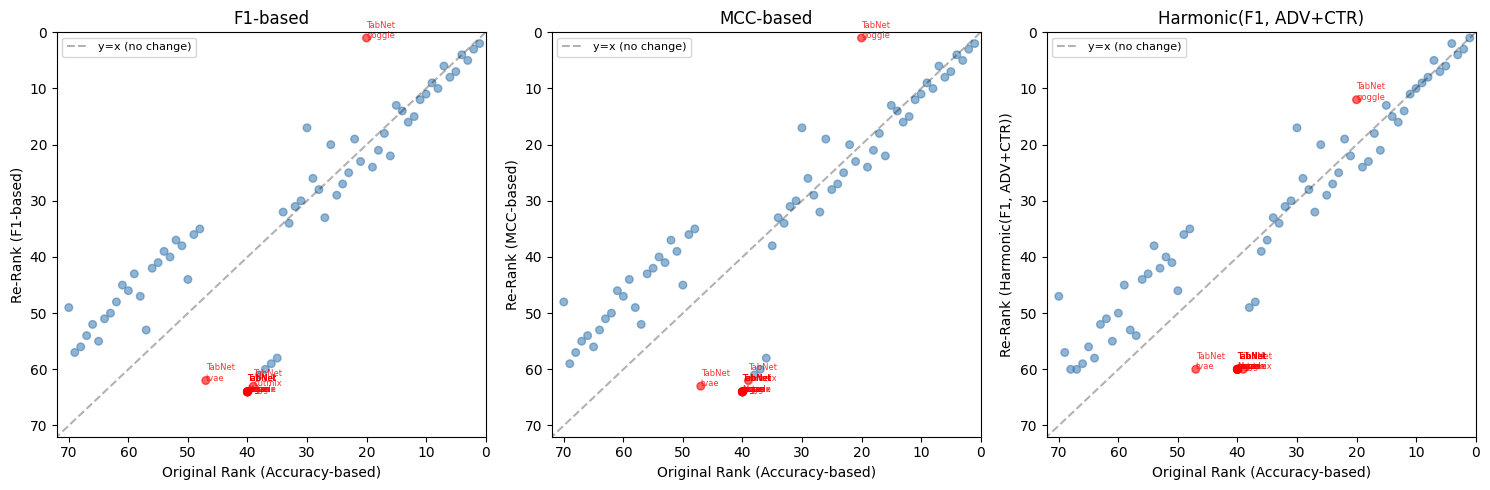

Saved: rank_sensitivity_lcld.png/pdf


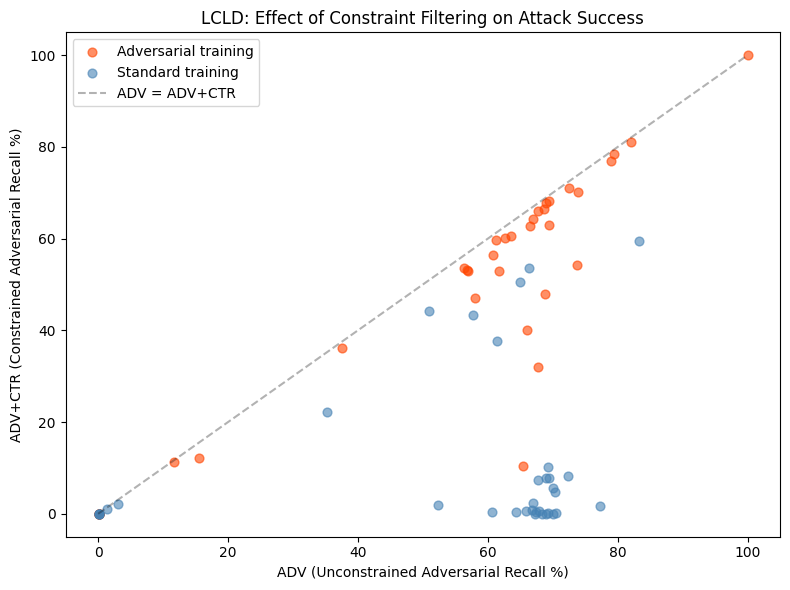

Saved: adv_vs_advctr_lcld.png


In [10]:
# Cell 10: Visualization (Direction 7 figures)

import matplotlib.pyplot as plt
import numpy as np

n_models = len(lcld_leaderboard)

# =====================================================================
# Figure 1: Rank shift scatter plot (3-panel)
# =====================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metric_pairs = [
    ("rank_score_original", "rank_score_f1", "F1-based"),
    ("rank_score_original", "rank_score_mcc", "MCC-based"),
    ("rank_score_original", "rank_score_harmonic", "Harmonic(F1, ADV+CTR)"),
]

for ax, (col_x, col_y, ylabel) in zip(axes, metric_pairs):
    x = lcld_leaderboard[col_x].values
    y = lcld_leaderboard[col_y].values

    colors = ["red" if d else "steelblue" for d in degenerate_mask]

    ax.scatter(x, y, c=colors, alpha=0.6, s=30)
    ax.plot([0, n_models + 2], [0, n_models + 2], "k--", alpha=0.3, label="y=x (no change)")
    ax.set_xlabel("Original Rank (Accuracy-based)")
    ax.set_ylabel(f"Re-Rank ({ylabel})")
    ax.set_title(ylabel)
    ax.set_xlim(0, n_models + 2)
    ax.set_ylim(0, n_models + 2)
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.legend(fontsize=8)

    # Annotate degenerate models
    for idx in lcld_leaderboard[degenerate_mask].index:
        row = lcld_leaderboard.loc[idx]
        ax.annotate(
            f"{row['arch']}\n{row['aug']}",
            (row[col_x], row[col_y]),
            fontsize=6, color="red", alpha=0.8
        )

plt.tight_layout()
plt.savefig("rank_sensitivity_lcld.png", dpi=150, bbox_inches="tight")
plt.savefig("rank_sensitivity_lcld.pdf", bbox_inches="tight")
plt.show()
print("Saved: rank_sensitivity_lcld.png/pdf")

# =====================================================================
# Figure 2: ADV vs ADV+CTR by training type
# =====================================================================

fig, ax = plt.subplots(figsize=(8, 6))

color_map = {"adversarial": "orangered", "standard": "steelblue"}
for training_type, color in color_map.items():
    subset = lcld_leaderboard[lcld_leaderboard["training"] == training_type]
    ax.scatter(
        subset["adv"] * 100, subset["adv_ctr"] * 100,
        c=color, alpha=0.6, s=40,
        label=f"{training_type.capitalize()} training"
    )

ax.plot([0, 100], [0, 100], "k--", alpha=0.3, label="ADV = ADV+CTR")
ax.set_xlabel("ADV (Unconstrained Adversarial Recall %)")
ax.set_ylabel("ADV+CTR (Constrained Adversarial Recall %)")
ax.set_title("LCLD: Effect of Constraint Filtering on Attack Success")
ax.legend()

plt.tight_layout()
plt.savefig("adv_vs_advctr_lcld.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: adv_vs_advctr_lcld.png")

In [11]:
# Cell 11: Combined summary narrative for paper

summary = f"""
======================================================================
           SUMMARY: TabularBench Metric Analysis
======================================================================

DIRECTION 3 -- ADV vs ADV+CTR GAP
----------------------------------
We mapped FraudBench's LCLD results into TabularBench's ADV/ADV+CTR
evaluation framework:

  * Clean Recall (ID):     {clean_recall:.4f} ({clean_recall*100:.2f}%)
  * ADV (unmasked):        {adv_unmasked:.4f} ({adv_unmasked*100:.2f}%)
  * ADV (masked):          {adv_masked:.4f} ({adv_masked*100:.2f}%)
  * ADV+CTR (unmasked):    {adv_ctr_unmasked:.4f} ({adv_ctr_unmasked*100:.2f}%)
  * ADV+CTR (masked):      {adv_ctr_masked:.4f} ({adv_ctr_masked*100:.2f}%)
  * Gap (unmasked):        {(adv_ctr_unmasked - adv_unmasked)*100:+.2f} pp
  * Gap (masked):          {(adv_ctr_masked - adv_masked)*100:+.2f} pp

Key finding: FraudBench's CAPGD attack is nearly 100% effective at
flipping positive predictions (ADV ~ 0%), but >99.8% of adversarial
examples violate domain constraints. Post-hoc constraint filtering
restores predictions to near-clean levels (ADV+CTR ~ clean recall).

This produces the LARGEST gap on the LCLD leaderboard — TabularBench's
constraint-aware CAA attack shows gaps of only 0.8-12.8 pp for
adversarially-trained models.

DIRECTION 7 -- RANKING METRIC SENSITIVITY
------------------------------------------
We re-ranked TabularBench's {len(lcld_leaderboard)}-model LCLD leaderboard
under alternative metrics:

  * Degenerate models found: {degenerate_mask.sum()}
    (achieving high ADV+CTR via trivial all-positive prediction)

  * Rank correlation (Original accuracy-based vs alternatives):
"""

for _, row in df_correlations.iterrows():
    summary += f"    {row['pair']:25s}: tau={row['kendall_tau']:.4f}, rho={row['spearman_rho']:.4f}\n"

summary += """
Key finding: Metric choice substantially changes model rankings.
Accuracy-based ranking (used by TabularBench) rewards degenerate models
and does not correlate strongly with metrics appropriate for imbalanced
fraud detection (F1, MCC).

This motivates FraudBench's design choice of PR-AUC as the primary
evaluation metric.
======================================================================
"""

print(summary)


           SUMMARY: TabularBench Metric Analysis

DIRECTION 3 -- ADV vs ADV+CTR GAP
----------------------------------
We mapped FraudBench's LCLD results into TabularBench's ADV/ADV+CTR
evaluation framework:

  * Clean Recall (ID):     0.5542 (55.42%)
  * ADV (unmasked):        0.0027 (0.27%)
  * ADV (masked):          0.0088 (0.88%)
  * ADV+CTR (unmasked):    0.5538 (55.38%)
  * ADV+CTR (masked):      0.5536 (55.36%)
  * Gap (unmasked):        +55.11 pp
  * Gap (masked):          +54.48 pp

Key finding: FraudBench's CAPGD attack is nearly 100% effective at
flipping positive predictions (ADV ~ 0%), but >99.8% of adversarial
examples violate domain constraints. Post-hoc constraint filtering
restores predictions to near-clean levels (ADV+CTR ~ clean recall).

This produces the LARGEST gap on the LCLD leaderboard — TabularBench's
constraint-aware CAA attack shows gaps of only 0.8-12.8 pp for
adversarially-trained models.

DIRECTION 7 -- RANKING METRIC SENSITIVITY
-----------------------

In [12]:
# Cell 12: Save all outputs to Google Drive

import os
import shutil

RESULTS_DST = "/content/drive/MyDrive/FraudBench/results/metric_analysis"
os.makedirs(RESULTS_DST, exist_ok=True)

# --- Direction 3 outputs ---
# ADV/ADV+CTR comparison CSV
adv_comparison = pd.DataFrame([
    {"variant": "unmasked", "clean_recall": clean_recall,
     "adv": adv_unmasked, "adv_ctr": adv_ctr_unmasked,
     "gap_pp": (adv_ctr_unmasked - adv_unmasked) * 100,
     "feasible_rate": feas_rate_un},
    {"variant": "masked", "clean_recall": clean_recall,
     "adv": adv_masked, "adv_ctr": adv_ctr_masked,
     "gap_pp": (adv_ctr_masked - adv_masked) * 100,
     "feasible_rate": feas_rate_mk},
])
adv_comparison.to_csv(os.path.join(RESULTS_DST, "adv_advctr_comparison.csv"), index=False)
print("  Saved: adv_advctr_comparison.csv")

# --- Direction 7 outputs ---
# Full re-ranked leaderboard
lcld_leaderboard.to_csv(os.path.join(RESULTS_DST, "lcld_leaderboard_reranked.csv"), index=False)
print("  Saved: lcld_leaderboard_reranked.csv")

# Rank correlation results
df_correlations.to_csv(os.path.join(RESULTS_DST, "rank_correlation_results.csv"), index=False)
print("  Saved: rank_correlation_results.csv")

# Figures
for fig_file in ["rank_sensitivity_lcld.png", "rank_sensitivity_lcld.pdf", "adv_vs_advctr_lcld.png"]:
    if os.path.exists(fig_file):
        shutil.copy2(fig_file, os.path.join(RESULTS_DST, fig_file))
        print(f"  Saved: {fig_file}")

# Summary text
with open(os.path.join(RESULTS_DST, "metric_analysis_summary.txt"), "w") as f:
    f.write(summary)
print("  Saved: metric_analysis_summary.txt")

print(f"\nAll results saved to {RESULTS_DST}")

  Saved: adv_advctr_comparison.csv
  Saved: lcld_leaderboard_reranked.csv
  Saved: rank_correlation_results.csv
  Saved: rank_sensitivity_lcld.png
  Saved: rank_sensitivity_lcld.pdf
  Saved: adv_vs_advctr_lcld.png
  Saved: metric_analysis_summary.txt

All results saved to /content/drive/MyDrive/FraudBench/results/metric_analysis
